https://github.com/zygmuntz/goodbooks-10k

In [ ]:
pip install kaggle

In [2]:
!pip uninstall -y numpy pandas

Found existing installation: numpy 1.21.5
Uninstalling numpy-1.21.5:
ERROR: Exception:
Traceback (most recent call last):
  File "/usr/local/anaconda3/lib/python3.9/shutil.py", line 825, in move
    os.rename(src, real_dst)
PermissionError: [Errno 13] Permission denied: '/usr/local/anaconda3/bin/f2py' -> '/tmp/pip-uninstall-580egjgj/f2py'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/moshtasa/.local/lib/python3.9/site-packages/pip/_internal/cli/base_command.py", line 105, in _run_wrapper
    status = _inner_run()
  File "/home/moshtasa/.local/lib/python3.9/site-packages/pip/_internal/cli/base_command.py", line 96, in _inner_run
    return self.run(options, args)
  File "/home/moshtasa/.local/lib/python3.9/site-packages/pip/_internal/commands/uninstall.py", line 106, in run
    uninstall_pathset = req.uninstall(
  File "/home/moshtasa/.local/lib/python3.9/site-packages/pip/_internal/req/req_install.py", line 723, i

In [ ]:
!pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable


In [7]:
!pip install numpy pandas

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
pip install kagglehub

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Define your local data path
data_path = '../data/goodbooks-10k'  # adjust path if needed

# Load all available CSV files
books = pd.read_csv(os.path.join(data_path, 'books.csv'))
ratings = pd.read_csv(os.path.join(data_path, 'ratings.csv'))
to_read = pd.read_csv(os.path.join(data_path, 'to_read.csv'))
book_tags = pd.read_csv(os.path.join(data_path, 'book_tags.csv'))
tags = pd.read_csv(os.path.join(data_path, 'tags.csv'))

# Quick verification:
print(f"books.csv shape: {books.shape}")
print(f"ratings.csv shape: {ratings.shape}")
print(f"to_read.csv shape: {to_read.shape}")
print(f"book_tags.csv shape: {book_tags.shape}")
print(f"tags.csv shape: {tags.shape}")

# Preview few rows from each file:
print("\nBooks sample:")
print(books.head())

print("\nRatings sample:")
print(ratings.head())

print("\nTo-Read sample:")
print(to_read.head())

print("\nBook Tags sample:")
print(book_tags.head())

print("\nTags sample:")
print(tags.head())


books.csv shape: (10000, 23)
ratings.csv shape: (5976479, 3)
to_read.csv shape: (912705, 2)
book_tags.csv shape: (999912, 3)
tags.csv shape: (34252, 2)

Books sample:
   book_id  goodreads_book_id  best_book_id  work_id  books_count       isbn  \
0        1            2767052       2767052  2792775          272  439023483   
1        2                  3             3  4640799          491  439554934   
2        3              41865         41865  3212258          226  316015849   
3        4               2657          2657  3275794          487   61120081   
4        5               4671          4671   245494         1356  743273567   

         isbn13                      authors  original_publication_year  \
0  9.780439e+12              Suzanne Collins                     2008.0   
1  9.780440e+12  J.K. Rowling, Mary GrandPré                     1997.0   
2  9.780316e+12              Stephenie Meyer                     2005.0   
3  9.780061e+12                   Harper Lee        

In [ ]:
# import pandas as pd
# import os

# # Load books.csv
# data_path = '../data/goodbooks-10k'
# books = pd.read_csv(os.path.join(data_path, 'books.csv'))

# # Total number of books
# total_books = len(books)

# # Total number of unique languages (excluding NaN)
# unique_languages = books['language_code'].nunique()

# # Number of books with missing language_code
# missing_languages = books['language_code'].isnull().sum()

# # Count number of books per language
# books_per_language = books['language_code'].value_counts()

# # Full list of languages
# languages_list = books['language_code'].dropna().unique()

# # Print summary
# print(f"Total number of books: {total_books}")
# print(f"Total unique languages: {unique_languages}")
# print(f"Number of books missing language info: {missing_languages}\n")

# print("Number of books per language:")
# print(books_per_language)

# print("\nList of languages:")
# print(languages_list)


In [22]:
import pandas as pd

# Load cleaned data
data_path = '../data/goodbooks-10k'
books = pd.read_csv(f"{data_path}/books.csv")
ratings = pd.read_csv(f"{data_path}/ratings.csv")

# Step 1: Create decade column
books['decade'] = (books['original_publication_year'] // 10) * 10

# Step 2: Group by conditions
def assign_decade_label(x):
    if pd.isna(x):
        return 'Not Available'
    elif x < 1920:
        return 'Ancient Books'
    else:
        return int(x)

books['decade_grouped'] = books['decade'].apply(assign_decade_label)

# Step 3: Merge ratings with books (attach decade info)
merged_df = ratings.merge(books[['book_id', 'decade_grouped']], on='book_id', how='left')

# Step 4: Rename columns for clarity
final_df = merged_df.rename(columns={'decade_grouped': 'decade'})

# Step 5: Reorder columns
final_df = final_df[['user_id', 'book_id', 'rating', 'decade']]

# Step 6: Save final dataset
final_df.to_csv("/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/df_final.csv", index=False)

# Print sample and shape for verification
print(final_df.head())
print(f"\nFinal dataset shape: {final_df.shape}")


   user_id  book_id  rating decade
0        1      258       5   2000
1        2     4081       4   2000
2        2      260       5   1930
3        2     9296       5   1970
4        2     2318       3   1990

Final dataset shape: (5976479, 4)


In [5]:
data_path = '../data'
df = pd.read_csv(f"{data_path}/df_final.csv")

In [6]:
# Count unique book_id per decade
books_per_decade = (
    df.groupby('decade')['book_id']
    .nunique()
    .reset_index(name='unique_books')
    .sort_values(by='decade')
)

print("\nUnique books per decade:")
print(books_per_decade)



Unique books per decade:
           decade  unique_books
0            1920            89
1            1930           121
2            1940           155
3            1950           210
4            1960           272
5            1970           400
6            1980           704
7            1990          1360
8            2000          3121
9            2010          3067
10  Ancient Books           480
11  Not Available            21


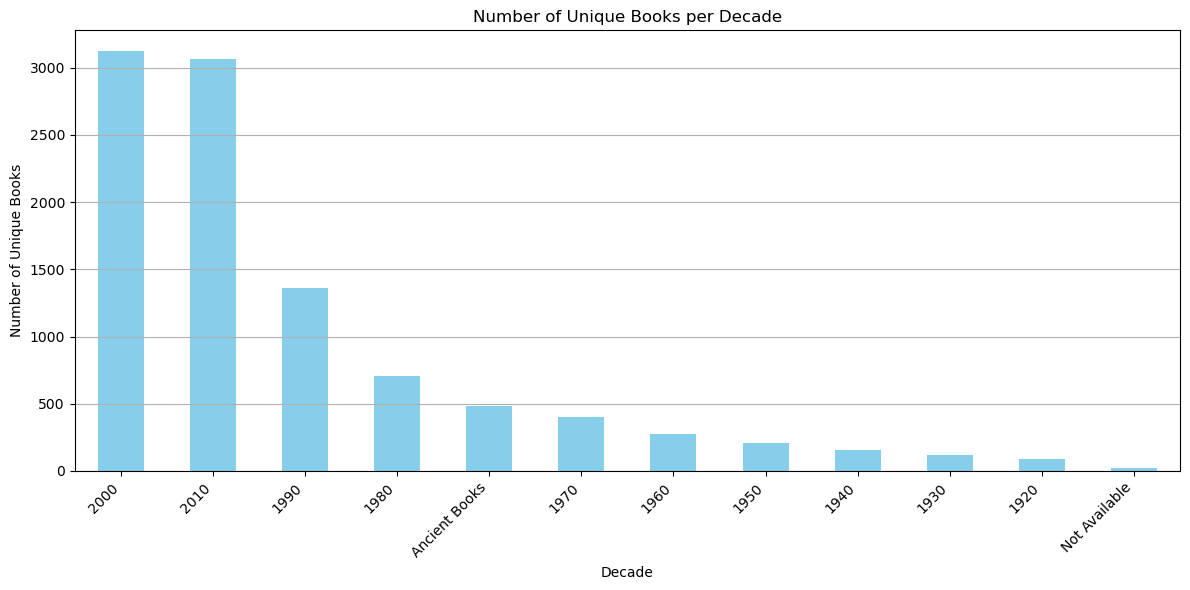


🔍 Missing Value Report:
Missing ratings: 0
Missing user IDs: 0
Missing book IDs: 0
Missing decades: 0

🧾 Number of duplicate rows: 0

📊 Total rows: 5976479
✅ Non-null ratings: 5976479
✔️ All rows have a rating.

📌 Dataset Summary:
Unique users: 53424
Unique books: 10000
Unique decades: 12
Average ratings per user: 111.87
Min ratings per user: 19
Max ratings per user: 200


In [7]:
import matplotlib.pyplot as plt

# ========== User & Book Statistics ==========
unique_users = df['user_id'].nunique()
unique_books = df['book_id'].nunique()
ratings_per_user = df.groupby('user_id').size()
average_ratings_per_user = ratings_per_user.mean()
min_ratings_per_user = ratings_per_user.min()
max_ratings_per_user = ratings_per_user.max()

# ========== Decade Statistics ==========
unique_decades = df['decade'].nunique()
books_per_decade = df.groupby('decade')['book_id'].nunique().sort_values(ascending=False)

# ========== Plot: Books per Decade ==========
plt.figure(figsize=(12, 6))
books_per_decade.plot(kind='bar', color='skyblue')
plt.title('Number of Unique Books per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

# ========== Missing Values ==========
missing_values = {
    "Missing ratings": df['rating'].isnull().sum(),
    "Missing user IDs": df['user_id'].isnull().sum(),
    "Missing book IDs": df['book_id'].isnull().sum(),
    "Missing decades": df['decade'].isnull().sum()
}

print("\n🔍 Missing Value Report:")
for key, val in missing_values.items():
    print(f"{key}: {val}")

# ========== Duplicate Rows ==========
duplicate_rows = df.duplicated().sum()
print(f"\n🧾 Number of duplicate rows: {duplicate_rows}")

# ========== Ratings Info ==========
total_rows = len(df)
non_null_ratings = df['rating'].notnull().sum()
print(f"\n📊 Total rows: {total_rows}")
print(f"✅ Non-null ratings: {non_null_ratings}")

if total_rows == non_null_ratings:
    print("✔️ All rows have a rating.")
else:
    print("⚠️ Some rows are missing a rating.")

# ========== Summary ==========
print("\n📌 Dataset Summary:")
print(f"Unique users: {unique_users}")
print(f"Unique books: {unique_books}")
print(f"Unique decades: {unique_decades}")
print(f"Average ratings per user: {average_ratings_per_user:.2f}")
print(f"Min ratings per user: {min_ratings_per_user}")
print(f"Max ratings per user: {max_ratings_per_user}")



In [8]:
import pandas as pd

# Load the books.csv file
data_path = '../data/goodbooks-10k'
books = pd.read_csv(os.path.join(data_path, 'books.csv'))

# Define common variations of J.K. Rowling's name
name_variations = [ 'sartre', 'sarter']

# Combine into a regex pattern for case-insensitive search
pattern = '|'.join(name_variations)

# Search for rows where the 'author' column contains any of the variations
rowling_books = books[books['authors'].str.lower().str.contains(pattern, na=False)]

# Display result
print(rowling_books['title'].unique())

['Nausea' 'Being and Nothingness' 'No Exit and Three Other Plays'
 'No Exit' 'The Wall' 'Existentialism Is a Humanism'
 'The Wretched of the Earth']


In [9]:
# Load the books.csv file
data_path = '../data/goodbooks-10k'
books = pd.read_csv(os.path.join(data_path, 'books.csv'))

# Count unique authors
unique_authors = books['authors'].nunique()

# Print the count
print(f"Number of unique authors: {unique_authors}")

Number of unique authors: 4664


In [10]:
# Define Persian language variations
persian_lang_variants = ['per', 'persian', 'fa']

# Filter rows where language column matches any variant (case-insensitive)
persian_books = books[books['language_code'].str.lower().isin(persian_lang_variants)]
# Show only the book titles
print(persian_books['title'])

6159       عقاید یک دلقک
6771        رباعيات خيام
7484              سینوهه
7638       درخت زیبای من
8335    ماهی سیاه کوچولو
8881       سمفونی مردگان
9857            هشت کتاب
Name: title, dtype: object


In [23]:
# Group by title and collect all unique years per title
title_years = books.groupby('title')['original_publication_year'].unique()

# Filter only titles that have more than 1 unique year
multiple_year_titles = title_years[title_years.apply(lambda x: len(x) > 1)]

# Print count
print(f"Number of titles with multiple publication years: {len(multiple_year_titles)}")

# Print sample (first 10 titles)
for title, years in multiple_year_titles.head(10).items():
    print(f"\nTitle: {title}")
    print(f"Years: {sorted(years)}")

# Total unique book IDs in ratings file
total_unique_books_in_ratings = ratings['book_id'].nunique()

# Total unique book IDs in books file (metadata)
total_unique_books_in_books = books['book_id'].nunique()



Number of titles with multiple publication years: 33

Title: 'Salem's Lot
Years: [1975.0, 2005.0]

Title: Anatomy for the Artist
Years: [1953.0, 2001.0]

Title: Arcadia
Years: [1993.0, 2012.0]

Title: Are You My Mother?
Years: [1960.0, 2012.0]

Title: Bambi
Years: [1923.0, 1941.0]

Title: Between the Lines (Between the Lines, #1)
Years: [2011.0, 2012.0]

Title: Invisible
Years: [2009.0, 2014.0]

Title: Leviathan
Years: [1651.0, 1992.0]

Title: Monster
Years: [1999.0, 2005.0]

Title: One Flew Over the Cuckoo's Nest
Years: [1962.0, 1970.0]


In [12]:
# Load data
data_path = '../data/goodbooks-10k'
books = pd.read_csv(f"{data_path}/books.csv")
ratings = pd.read_csv(f"{data_path}/ratings.csv")

# Create decade column and merge
books['decade'] = (books['original_publication_year'] // 10) * 10
merged_df = ratings.merge(books[['book_id', 'decade']], on='book_id')

# Groupby decade: count unique books & total ratings
summary = merged_df.groupby('decade').agg(
    unique_books=('book_id', 'nunique'),
    total_ratings=('rating', 'count')
).reset_index().sort_values('decade')

total_ratings_sum = summary['total_ratings'].sum()
print(f"Sum of total ratings from summary: {total_ratings_sum}")

total_ratings_actual = len(ratings)
print(f"Total number of ratings from ratings.csv: {total_ratings_actual}")


# Print results
print("Unique books per decade and total ratings:")
print(summary)


Sum of total ratings from summary: 5970537
Total number of ratings from ratings.csv: 5976479
Unique books per decade and total ratings:
    decade  unique_books  total_ratings
0  -1750.0             1            730
1   -770.0             1            756
2   -750.0             2           3944
3   -720.0             1           6301
4   -560.0             1           1548
..     ...           ...            ...
78  1970.0           400         244194
79  1980.0           704         443368
80  1990.0          1360         847948
81  2000.0          3121        1808808
82  2010.0          3067        1268418

[83 rows x 3 columns]


In [13]:
# How many unique book_ids exist in ratings but not in books
missing_books = set(ratings['book_id']) - set(books['book_id'])
print(f"Number of book_ids in ratings.csv not found in books.csv: {len(missing_books)}")

Number of book_ids in ratings.csv not found in books.csv: 0


In [14]:
total_books = books['book_id'].nunique()
print(f"Total unique books: {total_books}")

Total unique books: 10000


In [21]:
total_ratings = len(ratings)
print(f"Total ratings: {total_ratings}")

Total ratings: 5976479


In [16]:
# Add decade
books['decade'] = (books['original_publication_year'] // 10) * 10

# Count books per decade (this is from full books.csv not merged one!)
books_per_decade = books.groupby('decade')['book_id'].nunique().reset_index(name='unique_books')

# Summation of books across decades
total_books_from_decades = books_per_decade['unique_books'].sum()

print("Books per decade:")
print(books_per_decade)
print(f"\nSummation of books across decades: {total_books_from_decades}")


Books per decade:
    decade  unique_books
0  -1750.0             1
1   -770.0             1
2   -750.0             2
3   -720.0             1
4   -560.0             1
..     ...           ...
78  1970.0           400
79  1980.0           704
80  1990.0          1360
81  2000.0          3121
82  2010.0          3067

[83 rows x 2 columns]

Summation of books across decades: 9979


In [18]:
# Load cleaned data
data_path = '../data/goodbooks-10k'
books = pd.read_csv(f"{data_path}/books.csv")
ratings = pd.read_csv(f"{data_path}/ratings.csv")

# 1️⃣ Count unique book_id in books.csv
unique_books_in_books = books['book_id'].nunique()
print(f"Total unique book_ids in books.csv: {unique_books_in_books}")

# 2️⃣ Count unique book_id in ratings.csv
unique_books_in_ratings = ratings['book_id'].nunique()
print(f"Total unique book_ids in ratings.csv: {unique_books_in_ratings}")

# 3️⃣ Count total ratings
total_ratings = len(ratings)
print(f"Total ratings: {total_ratings}")

# 4️⃣ Compute decade column
books['decade'] = (books['original_publication_year'] // 10) * 10

# 5️⃣ Count number of unique books per decade
books_per_decade = books.groupby('decade')['book_id'].nunique().reset_index(name='unique_books_per_decade')
books_per_decade = books_per_decade.sort_values('decade')

print("\nBooks per decade:")
print(books_per_decade)

# 6️⃣ Verify summation of books across decades
total_books_from_decades = books_per_decade['unique_books_per_decade'].sum()
print(f"\nSummation of books across decades: {total_books_from_decades}")


Total unique book_ids in books.csv: 10000
Total unique book_ids in ratings.csv: 10000
Total ratings: 5976479

Books per decade:
    decade  unique_books_per_decade
0  -1750.0                        1
1   -770.0                        1
2   -750.0                        2
3   -720.0                        1
4   -560.0                        1
..     ...                      ...
78  1970.0                      400
79  1980.0                      704
80  1990.0                     1360
81  2000.0                     3121
82  2010.0                     3067

[83 rows x 2 columns]

Summation of books across decades: 9979


In [19]:
books_per_decade

,decade,unique_books_per_decade
0,-1750.0,1
1,-770.0,1
2,-750.0,2
3,-720.0,1
4,-560.0,1
...,...,...
78,1970.0,400
79,1980.0,704
80,1990.0,1360
81,2000.0,3121


## computing user_entropy and clustering - initiate

In [24]:
# Step 1: Count number of ratings per user per decade
user_decade_counts = final_df.groupby(['user_id', 'decade']).size().unstack(fill_value=0)

# Step 2: Normalize counts so each user's row sums to 1
user_decade_normalized = user_decade_counts.div(user_decade_counts.sum(axis=1), axis=0)

# Step 3: Rename columns to indicate normalization
user_decade_normalized.columns = [f'{c}_norm' for c in user_decade_normalized.columns]

# Step 4: Merge raw counts with normalized values
user_decade_merged = pd.concat([user_decade_counts, user_decade_normalized], axis=1).reset_index()

# Step 5: Preview the result
print(user_decade_merged.head())


   user_id  1920  1930  1940  1950  1960  1970  1980  1990  2000  ...  \
0        1     0     3     4     3     4     2    15     9    48  ...   
1        2     2     3     2     4     2     4     2    12    21  ...   
2        3     3     5     6     5     4     3     9    21    19  ...   
3        4     4     7     7    10    14     9    20    24    24  ...   
4        5     0     1     0     1     1     1    10    11    17  ...   

   1940_norm  1950_norm  1960_norm  1970_norm  1980_norm  1990_norm  \
0   0.034188   0.025641   0.034188   0.017094   0.128205   0.076923   
1   0.030769   0.061538   0.030769   0.061538   0.030769   0.184615   
2   0.065934   0.054945   0.043956   0.032967   0.098901   0.230769   
3   0.052239   0.074627   0.104478   0.067164   0.149254   0.179104   
4   0.000000   0.010000   0.010000   0.010000   0.100000   0.110000   

   2000_norm  2010_norm  Ancient Books_norm  Not Available_norm  
0   0.410256   0.119658            0.128205                 0.0  
1 


✅ User entropy file saved: ../preprocessing/user_entropy_quantile_books.csv


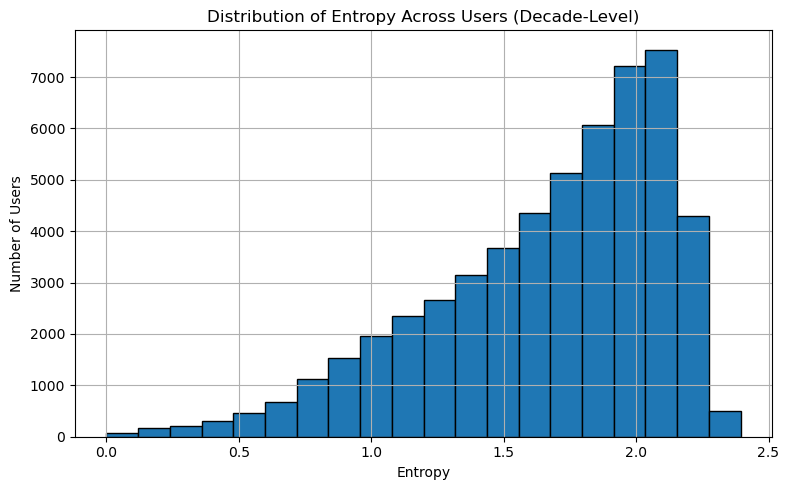


Entropy histogram distribution:
Entropy range [0.000, 0.120): 63 users
Entropy range [0.120, 0.239): 170 users
Entropy range [0.239, 0.359): 203 users
Entropy range [0.359, 0.479): 305 users
Entropy range [0.479, 0.599): 463 users
Entropy range [0.599, 0.718): 678 users
Entropy range [0.718, 0.838): 1117 users
Entropy range [0.838, 0.958): 1538 users
Entropy range [0.958, 1.077): 1962 users
Entropy range [1.077, 1.197): 2348 users
Entropy range [1.197, 1.317): 2663 users
Entropy range [1.317, 1.437): 3149 users
Entropy range [1.437, 1.556): 3680 users
Entropy range [1.556, 1.676): 4357 users
Entropy range [1.676, 1.796): 5137 users
Entropy range [1.796, 1.916): 6061 users
Entropy range [1.916, 2.035): 7208 users
Entropy range [2.035, 2.155): 7533 users
Entropy range [2.155, 2.275): 4290 users
Entropy range [2.275, 2.394): 499 users


In [25]:
import pandas as pd
from scipy.stats import entropy
import matplotlib.pyplot as plt

# Step 1: Count how many books each user rated in each decade
user_decade_counts = final_df.groupby(['user_id', 'decade']).size().unstack(fill_value=0)

# Step 2: Normalize counts to get per-user decade distributions
user_decade_normalized = user_decade_counts.div(user_decade_counts.sum(axis=1), axis=0)
user_decade_normalized.columns = [f"{c}_norm" for c in user_decade_normalized.columns]

# Step 3: Calculate entropy (diversity of preferences) per user
user_entropy = user_decade_normalized.apply(lambda x: entropy(x), axis=1).to_frame(name='entropy')
user_entropy.reset_index(inplace=True)

# Step 4: Quantile-Based Clustering (3 clusters: low, mid, high diversity)
user_entropy_sorted = user_entropy.sort_values(by='entropy').reset_index(drop=True)
n_users = len(user_entropy_sorted)
user_entropy_sorted['cluster'] = pd.cut(
    user_entropy_sorted.index,
    bins=[-1, n_users // 3, 2 * n_users // 3, n_users],
    labels=[0, 1, 2]
).astype(int)

# Optional: Save the result
output_path = "../preprocessing/user_entropy_quantile_books.csv"
user_entropy_sorted.to_csv(output_path, index=False)
print(f"\n✅ User entropy file saved: {output_path}")

# Step 5: Plot histogram of entropy values & get counts
plt.figure(figsize=(8, 5))
counts, bin_edges, _ = plt.hist(user_entropy_sorted['entropy'], bins=20, edgecolor='black')
plt.title('Distribution of Entropy Across Users (Decade-Level)')
plt.xlabel('Entropy')
plt.ylabel('Number of Users')
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ Print the histogram distribution as text
print("\nEntropy histogram distribution:")
for i in range(len(counts)):
    print(f"Entropy range [{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f}): {int(counts[i])} users")


#### leave the clustering steps 


In [10]:
import pandas as pd
import os

data_path = '../data/goodbooks-10k'
books = pd.read_csv(os.path.join(data_path, 'books.csv'))

# Select columns by passing a list of their names as strings
subset = books[['book_id', 'title', 'authors', 'original_title']]

subset.head()


,book_id,title,authors,original_title
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,The Hunger Games
1,2,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",Harry Potter and the Philosopher's Stone
2,3,"Twilight (Twilight, #1)",Stephenie Meyer,Twilight
3,4,To Kill a Mockingbird,Harper Lee,To Kill a Mockingbird
4,5,The Great Gatsby,F. Scott Fitzgerald,The Great Gatsby


In [26]:
books["original_title"].nunique()

9274

## LLM

In [3]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import transformers
import torch

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

pipeline = transformers.pipeline(
    "text-generation",
    model=model_id,
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto",
)

messages = [
    {"role": "system", "content": "You are a pirate chatbot who always responds in pirate speak!"},
    {"role": "user", "content": "Who are you?"},
]

outputs = pipeline(
    messages,
    max_new_tokens=256,
)
print(outputs[0]["generated_text"][-1])


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Meta-Llama-3.1-8B-Instruct.
403 Client Error. (Request ID: Root=1-68714434-396d5aa003fa42724105c612;7522bfd6-1cf9-471c-8528-1fdcfd770e83)

Cannot access gated repo for url https://huggingface.co/meta-llama/Meta-Llama-3.1-8B-Instruct/resolve/main/config.json.
Your request to access model meta-llama/Llama-3.1-8B-Instruct has been rejected by the repo's authors.

In [ ]:

from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
import multiprocessing as mp
import re

# === Define the sample books dataset
sample_books = [
    {"book_id": 1, "original_title": "The Hobbit", "authors": "J.R.R. Tolkien"},
    {"book_id": 2, "original_title": "Pride and Prejudice", "authors": "Jane Austen"},
    {"book_id": 3, "original_title": "The Shining", "authors": "Stephen King"},
    {"book_id": 4, "original_title": "Dune", "authors": "Frank Herbert"},
    {"book_id": 5, "original_title": "The Diary of a Young Girl", "authors": "Anne Frank"},
    {"book_id": 6, "original_title": "Charlotte's Web", "authors": "E.B. White"},
    {"book_id": 7, "original_title": "The Da Vinci Code", "authors": "Dan Brown"},
    {"book_id": 8, "original_title": "Dracula", "authors": "Bram Stoker"},
    {"book_id": 9, "original_title": "War and Peace", "authors": "Leo Tolstoy"},
    {"book_id": 10, "original_title": "Fifty Shades of Grey", "authors": "E.L. James"},
    {"book_id": 11, "original_title": "Harry Potter and the Sorcerer's Stone", "authors": "J.K. Rowling"},
    {"book_id": 12, "original_title": "To Kill a Mockingbird", "authors": "Harper Lee"},
    {"book_id": 13, "original_title": "The Great Gatsby", "authors": "F. Scott Fitzgerald"},
    {"book_id": 14, "original_title": "The Hunger Games", "authors": "Suzanne Collins"},
    {"book_id": 15, "original_title": "Moby-Dick", "authors": "Herman Melville"},
]

df_books_sample = pd.DataFrame(sample_books)

GENRE_LIST = [
    "Fantasy", "Science Fiction", "Romance", "Mystery", "Thriller",
    "Historical", "Adult", "Horror", "Children's",
    "Adventure", "Classics", "Nonfiction", "Drama"
]
genre_options_str = ", ".join(GENRE_LIST)

# === Global pipe for multiprocessing
global_pipe = None

def init_model(model_name):
    """Initialize model pipeline in each worker process."""
    global global_pipe
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if "flan" in model_name.lower() or "t5" in model_name.lower():
        from transformers import AutoModelForSeq2SeqLM
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
        global_pipe = pipeline("text2text-generation", model=model, tokenizer=tokenizer)
    else:
        model = AutoModelForCausalLM.from_pretrained(model_name)
        global_pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

def process_book(row):
    """Process a single book, returns exactly two predicted genres."""
    global global_pipe
    title = row['original_title']
    author = row['authors']

    prompt = f"""
You are a book genre classifier. Your job is to pick exactly two genres from the list below that best match the book title (and author, if given).

Examples:
- "The Hobbit" → Fantasy, Adventure
- "Pride and Prejudice" → Romance, Classics
- "The Shining" → Horror, Thriller

Now choose the two most appropriate genres for:
Title: "{title}"{f" by {author}" if author else ""}

Genres: {genre_options_str}
Respond ONLY with two genres separated by a comma.
"""
    result = global_pipe(prompt.strip(), max_new_tokens=50, temperature=0.2)
    raw_output = result[0]['generated_text'].strip()

    # Extract first two valid genres from the output using regex
    pattern = r"\b(" + "|".join(re.escape(genre) for genre in GENRE_LIST) + r")\b\s*,\s*\b(" + "|".join(re.escape(genre) for genre in GENRE_LIST) + r")\b"
    match = re.search(pattern, raw_output, re.IGNORECASE)
    if match:
        return f"{match.group(1)}, {match.group(2)}"

    return raw_output  # fallback: return raw output for inspection

def process_and_save_parallel(model_name, output_filename, num_workers=2):
    print(f"\n🚀 Loading model: {model_name} on {num_workers} parallel workers...")


    with mp.Pool(
        processes=num_workers,
        initializer=init_model,
        initargs=(model_name,)
    ) as pool:
        genres = list(tqdm(
            pool.imap(process_book, df_books_sample.to_dict(orient="records")),
            total=len(df_books_sample)
        ))

    df_books_sample['genres'] = genres
    df_books_sample.to_csv(output_filename, index=False)
    print(f"✅ Saved genres dataset: {output_filename}")

if __name__ == "__main__":
    tasks = [
        ("meta-llama/Llama-3-8b-instruct", "../data/LLM/books_genres_llama3.csv"),
    ]
    num_workers = 2

    for model_name, output_filename in tasks:
        process_and_save_parallel(model_name, output_filename, num_workers)

    print("🎉 All models finished processing!")


# if __name__ == "__main__":
#     tasks = [
#         # Uncomment or add models as needed:
#        # ("HuggingFaceH4/zephyr-7b-beta", "../data/test/books_genres_zephyr.csv"),
#       #  ("mistralai/Mistral-7B-Instruct-v0.2", "../data/test/books_genres_mistral.csv"),
#        # ("meta-llama/Llama-3-8b-instruct", "../data/test/books_genres_llama3.csv"),
#       #  ("microsoft/phi-2", "../data/test/books_genres_phi2.csv"),
#         ("google/flan-t5-xl", "../data/test_llm/books_genres_flan_t5.csv"),
#     ]
#     num_workers = 2  # reduce workers to avoid overloading your server

#     processes = []
#     for model_name, output_filename in tasks:
#         p = mp.Process(
#             target=process_and_save_parallel,
#             args=(model_name, output_filename, num_workers)
#         )
#         p.start()
#         processes.append(p)

#     for p in processes:
#         p.join()

#     print("🎉 All models finished processing!")


## books_genres_flan_t5

In [ ]:
import os
import pandas as pd
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
import multiprocessing as mp
import re

# === Load dataset once globally ===
data_path = '../data/goodbooks-10k'
books = pd.read_csv(os.path.join(data_path, 'books.csv'))
df_books = books[['book_id', 'original_title', 'authors']].dropna(subset=['original_title'])
# === Sample 15 books for testing ===
sample_books = df_books.sample(n=100, random_state=42).reset_index(drop=True)

df_books_sample = pd.DataFrame(sample_books)

GENRE_LIST = [
    "Fantasy", "Science Fiction", "Romance", "Mystery", "Thriller",
    "Historical", "Adult", "Horror", "Children's",
    "Adventure", "Classics", "Nonfiction", "Drama"
]
genre_options_str = ", ".join(GENRE_LIST)

# === Global pipe for multiprocessing
global_pipe = None

def init_model(model_name):
    """Initialize model pipeline in each worker process."""
    global global_pipe
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if "flan" in model_name.lower() or "t5" in model_name.lower():
        from transformers import AutoModelForSeq2SeqLM
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
        global_pipe = pipeline("text2text-generation", model=model, tokenizer=tokenizer)
    else:
        model = AutoModelForCausalLM.from_pretrained(model_name)
        global_pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

def process_book(row):
    """Process a single book, returns exactly two predicted genres."""
    global global_pipe
    title = row['original_title']
    author = row['authors']

    prompt = f"""
You are a book genre classifier. Your job is to pick exactly two genres from the list below that best match the book title (and author, if given).

Examples:
- "The Hobbit" → Fantasy, Adventure
- "Pride and Prejudice" → Romance, Classics
- "The Shining" → Horror, Thriller

Now choose the two most appropriate genres for:
Title: "{title}"{f" by {author}" if author else ""}

Genres: {genre_options_str}
Respond ONLY with two genres separated by a comma.
"""
    result = global_pipe(prompt.strip(), max_new_tokens=50, temperature=0.2)
    raw_output = result[0]['generated_text'].strip()

    # Extract first two valid genres from the output using regex
    pattern = r"\b(" + "|".join(re.escape(genre) for genre in GENRE_LIST) + r")\b\s*,\s*\b(" + "|".join(re.escape(genre) for genre in GENRE_LIST) + r")\b"
    match = re.search(pattern, raw_output, re.IGNORECASE)
    if match:
        return f"{match.group(1)}, {match.group(2)}"

    return raw_output  # fallback: return raw output for inspection

def process_and_save_parallel(model_name, output_filename, num_workers=2):
    print(f"\n🚀 Loading model: {model_name} on {num_workers} parallel workers...")


    with mp.Pool(
        processes=num_workers,
        initializer=init_model,
        initargs=(model_name,)
    ) as pool:
        genres = list(tqdm(
            pool.imap(process_book, df_books_sample.to_dict(orient="records")),
            total=len(df_books_sample)
        ))

    df_books_sample['genres'] = genres
    df_books_sample.to_csv(output_filename, index=False)
    print(f"✅ Saved genres dataset: {output_filename}")

if __name__ == "__main__":
    tasks = [
       ("google/flan-t5-xl", "../data/LLM/books_genres_flan_t5.csv"),
    ]
    num_workers = 2

    for model_name, output_filename in tasks:
        process_and_save_parallel(model_name, output_filename, num_workers)

    print("🎉 All models finished processing!")

## zeroshot model

In [ ]:
import os
import pandas as pd
from transformers import pipeline
from tqdm import tqdm

# === Load dataset ===
data_path = '../data/goodbooks-10k'
books = pd.read_csv(os.path.join(data_path, 'books.csv'))
df_books = books[['book_id', 'original_title', 'authors']].dropna(subset=['original_title']).reset_index(drop=True)

GENRE_LIST = [
    "Fantasy", "Science Fiction", "Romance", "Mystery", "Thriller",
    "Historical", "Adult", "Horror", "Children's",
    "Adventure", "Classics", "Nonfiction", "Drama"
]

# === Initialize zero-shot classification pipeline ===
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

genres_predicted = []
output_path = "/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/LLM/10k_zeroshot.csv"


BATCH_SIZE = 100
for i, start in enumerate(tqdm(range(0, len(df_books), BATCH_SIZE), desc="Processing batches"), 1):
    end = min(start + BATCH_SIZE, len(df_books))
    batch_df = df_books.iloc[start:end]
    titles = [f"{title} by {author}" for title, author in zip(batch_df['original_title'], batch_df['authors'])]
    results = classifier(titles, GENRE_LIST, multi_label=True)
    for result, title in zip(results, titles):
        top2 = sorted(zip(result['labels'], result['scores']), key=lambda x: -x[1])[:2]
        top2_genres = f"{top2[0][0]}, {top2[1][0]}"
        genres_predicted.append(top2_genres)
        print(f"{title} → {top2_genres}")

    # Save predictions incrementally after each batch
    df_books_partial = df_books.iloc[:end].copy()
    df_books_partial['genres'] = genres_predicted
    df_books_partial.to_csv(output_path, index=False)
    print(f"💾 Batch {i}: Saved predictions for rows 0 to {end-1} to {output_path}")

print(f"\n✅ All books processed and final genres saved to {output_path}!")


## OpenAI 

## original

In [ ]:
import os
import openai
import pandas as pd
from tqdm import tqdm



# === Load Dataset ===
data_path = '../data/goodbooks-10k'
books = pd.read_csv(os.path.join(data_path, 'books.csv'))
df_books = books[['book_id', 'original_title', 'authors']].dropna(subset=['original_title']).reset_index(drop=True)
# df_books = df_books.sample(n=10, random_state=42).reset_index(drop=True)

# === Genre List ===
GENRE_LIST = [
    "Fantasy", "Science Fiction", "Romance", "Mystery", "Thriller",
    "Historical", "Adult", "Horror", "Children's", "Adventure",
    "Classics", "Nonfiction", "Drama"
]
GENRE_SET = set(GENRE_LIST)

# === Settings ===
BATCH_SIZE = 10
SAVE_EVERY = 100
output_path = "/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/LLM/10k_gpt_genres.csv"
genres_predicted = []

# === Prompt Format ===
def format_prompt(book_batch):
    prompt = (
        "You are a book genre classifier.\n"
        "For each book in the list below, choose exactly TWO genres from the following list:\n"
        f"{', '.join(GENRE_LIST)}\n\n"
        "Rules:\n"
        "- Only output genre names.\n"
        "- No numbering or extra text.\n"
        "- Each line = exactly 2 genres, comma-separated, e.g., Fantasy, Adventure\n\n"
        "Books:\n"
    )
    for row in book_batch.itertuples(index=False):
        prompt += f"{row.original_title} by {row.authors}\n"
    return prompt

# === Call OpenAI ===
def call_openai(prompt):
    response = openai_client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that classifies book genres."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.2
    )
    return response.choices[0].message.content.strip()

# === Validate and Clean Genre Output ===
def validate_genres(response, expected_count):
    lines = [line.strip() for line in response.split("\n") if line.strip()]
    valid = []
    for line in lines:
        genres = [g.strip() for g in line.split(",") if g.strip() in GENRE_SET]
        if len(genres) == 2:
            valid.append(", ".join(genres))
    # If the result has fewer than expected, repeat the last valid line
    while len(valid) < expected_count:
        valid.append(valid[-1] if valid else "Fantasy, Adventure")
    return valid[:expected_count]

# === Main Batch Loop ===
for i, start in enumerate(tqdm(range(0, len(df_books), BATCH_SIZE), desc="Processing batches"), 1):
    end = min(start + BATCH_SIZE, len(df_books))
    book_batch = df_books.iloc[start:end]
    prompt = format_prompt(book_batch)

    try:
        genres_raw = call_openai(prompt)
        genres_list = validate_genres(genres_raw, len(book_batch))
        genres_predicted.extend(genres_list)
    except Exception as e:
        print(f"❌ Error on batch {i} ({start}-{end}): {e}")
        genres_predicted.extend(["Fantasy, Adventure"] * len(book_batch))  # default fallback

    # Save progress
    if end % SAVE_EVERY == 0 or end == len(df_books):
        df_books_partial = df_books.iloc[:end].copy()
        df_books_partial['genres'] = genres_predicted
        df_books_partial.to_csv(output_path, index=False)
        print(f"💾 Batch {i}: Saved predictions for rows 0 to {end - 1} to {output_path}")

print(f"\n✅ All books processed and saved to {output_path}!")


## comparision

✅ Unique book ID counts:
books.csv      : 9415
FLAN-T5        : 9415
Zero-shot      : 9415
GPT-3.5 : 9415

📊 Genre counts (Zero-shot vs FLAN-T5 vs GPT-3.5):

Adult           | Zero-shot:  4056 | FLAN-T5:   839 | GPT-3.5:   331
Adventure       | Zero-shot:   392 | FLAN-T5:   316 | GPT-3.5:  1789
Children's      | Zero-shot:   702 | FLAN-T5:  1159 | GPT-3.5:   863
Classics        | Zero-shot:   766 | FLAN-T5:   188 | GPT-3.5:   901
Drama           | Zero-shot:  1507 | FLAN-T5:  1284 | GPT-3.5:  3006
Fantasy         | Zero-shot:   759 | FLAN-T5:  1794 | GPT-3.5:  2088
Historical      | Zero-shot:  1714 | FLAN-T5:   957 | GPT-3.5:   857
Horror          | Zero-shot:  1250 | FLAN-T5:    48 | GPT-3.5:   769
Mystery         | Zero-shot:   393 | FLAN-T5:  1847 | GPT-3.5:  2563
Nonfiction      | Zero-shot:  4019 | FLAN-T5:  1988 | GPT-3.5:  1071
Romance         | Zero-shot:   703 | FLAN-T5:  2028 | GPT-3.5:  2131
Science Fiction | Zero-shot:  2160 | FLAN-T5:  1023 | GPT-3.5:   855
Thriller      

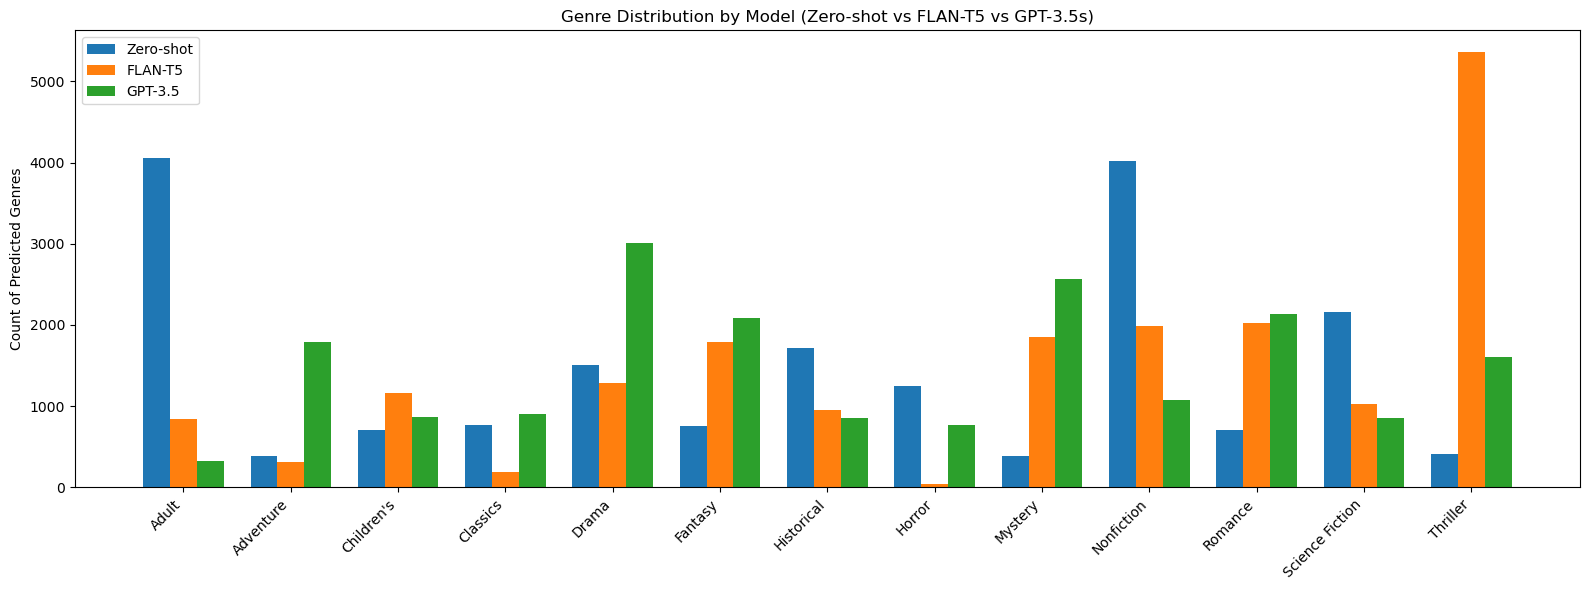

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

# === Load datasets ===
df_flan = pd.read_csv("/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/LLM/10k_flan_t5.csv")
df_zeroshot = pd.read_csv("/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/LLM/10k_zeroshot.csv")
df_gpt = pd.read_csv("/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/LLM/10k_gpt_genres.csv")


books = pd.read_csv("../data/goodbooks-10k/books.csv")
books = books[['book_id', 'original_title', 'authors']].dropna(subset=['original_title']).reset_index(drop=True)

# === Count unique book IDs ===
print("✅ Unique book ID counts:")
print(f"books.csv      : {books['book_id'].nunique()}")
print(f"FLAN-T5        : {df_flan['book_id'].nunique()}")
print(f"Zero-shot      : {df_zeroshot['book_id'].nunique()}")
print(f"GPT-3.5 : {df_gpt['book_id'].nunique()}")

# === Clean GPT genres and count ===
def count_genres_clean_gpt(df):
    genre_counter = Counter()
    for entry in df['genres'].dropna():
        if ':' in entry:
            genre_str = entry.split(':', 1)[1]
        else:
            genre_str = re.sub(r"^\d+\.\s*", "", entry)
        genres = [g.strip() for g in genre_str.split(',') if g.strip()]
        for genre in genres:
            genre_counter[genre] += 1
    return genre_counter

# === Simple counter for FLAN and Zero-shot ===
def count_genres(df):
    genre_counter = Counter()
    for entry in df['genres'].dropna():
        genres = [g.strip() for g in entry.split(',') if g.strip()]
        for genre in genres:
            genre_counter[genre] += 1
    return genre_counter

# === Count genres per model ===
counts_zeroshot = count_genres(df_zeroshot)
counts_flan = count_genres(df_flan)
counts_gpt = count_genres_clean_gpt(df_gpt)

# === Create union of all genres ===
all_genres = sorted(set(counts_zeroshot.keys()).union(counts_flan.keys()).union(counts_gpt.keys()))
zeroshot_values = [counts_zeroshot.get(g, 0) for g in all_genres]
flan_values = [counts_flan.get(g, 0) for g in all_genres]
gpt_values = [counts_gpt.get(g, 0) for g in all_genres]

# === Display raw counts
print("\n📊 Genre counts (Zero-shot vs FLAN-T5 vs GPT-3.5):\n")
for genre, z, f, g in zip(all_genres, zeroshot_values, flan_values, gpt_values):
    print(f"{genre:15s} | Zero-shot: {z:5d} | FLAN-T5: {f:5d} | GPT-3.5: {g:5d}")

# === Bar plot ===
x = range(len(all_genres))
width = 0.25

plt.figure(figsize=(16, 6))
plt.bar(x, zeroshot_values, width=width, label="Zero-shot")
plt.bar([i + width for i in x], flan_values, width=width, label="FLAN-T5")
plt.bar([i + 2 * width for i in x], gpt_values, width=width, label="GPT-3.5")

plt.xticks([i + width for i in x], all_genres, rotation=45, ha='right')
plt.ylabel("Count of Predicted Genres")
plt.title("Genre Distribution by Model (Zero-shot vs FLAN-T5 vs GPT-3.5s)")
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
import pandas as pd

# Path to your GPT genre file
gpt_path = "/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/LLM/10k_gpt_genres.csv"

# Load the file
df_gpt = pd.read_csv(gpt_path)

# Drop rows with missing or empty genre values
df_gpt_clean = df_gpt.dropna(subset=["genres"])
df_gpt_clean = df_gpt_clean[df_gpt_clean["genres"].str.strip() != ""]

# Count number of rows
count = len(df_gpt_clean)

print(f"✅ GPT-3.5 genre-assigned book count: {count}")


✅ GPT-3.5 genre-assigned book count: 9415


In [4]:
df_zeroshot.sample(10)
# df[['original_title', 'authors']]

,book_id,original_title,authors,genres
7954,8377,Open Season,C.J. Box,"Drama, Science Fiction"
7471,7841,A Place Called Freedom,Ken Follett,"Nonfiction, Adult"
192,195,The Guernsey Literary and Potato Peel Pie Society,"Mary Ann Shaffer, Annie Barrows","Historical, Adult"
5969,6212,Peril at End House,Agatha Christie,"Classics, Drama"
5790,6021,Comfort Me with Apples: More Adventures at the...,Ruth Reichl,"Adventure, Nonfiction"
465,475,Where She Went,Gayle Forman,"Nonfiction, Adventure"
7702,8101,The Five Greatest Warriors,Matthew Reilly,"Nonfiction, Adult"
8181,8623,Billions and Billions: Thoughts on Life and De...,"Carl Sagan, Ann Druyan","Nonfiction, Adult"
1904,1950,Hellboy: Seed of Destruction,"Mike Mignola, John Byrne","Horror, Adult"
3713,3836,The Magic Faraway Tree,Enid Blyton,"Fantasy, Children's"


In [5]:
# === Data ===
data = [
    {"original_title": "Stardust", "authors": "Neil Gaiman", "genres": "Fantasy, Adventure"},
    {"original_title": "The Velveteen Rabbit", "authors": "Margery Williams Bianco, William Nicholson", "genres": "Children's, Classics"},
    {"original_title": "Animal Farm: A Fairy Story", "authors": "George Orwell", "genres": "Classics, Drama"},
    {"original_title": "Nickel and Dimed: On (Not) Getting By in America", "authors": "Barbara Ehrenreich", "genres": "Nonfiction, Adult"},
    {"original_title": "Lean In: Women, Work, and the Will to Lead", "authors": "Sheryl Sandberg, Nell Scovell", "genres": "Nonfiction, Adult"},
    {"original_title": "The Historian", "authors": "Elizabeth Kostova", "genres": "Mystery, Historical"},
    {"original_title": "Roots", "authors": "Alex Haley", "genres": "Historical, Drama"},
    {"original_title": "Scott Pilgrim, Volume 1: Scott Pilgrim's Precious Little Life", "authors": "Bryan Lee O'Malley", "genres": "Fantasy, Adventure"},
    {"original_title": "City of Heavenly Fire", "authors": "Cassandra Clare", "genres": "Fantasy, Adventure"},
    {"original_title": "Мастер и Маргарита", "authors": "Mikhail Bulgakov, Katherine Tiernan O'Connor, others", "genres": "Fantasy, Classics"},
]

# === Create DataFrame ===
df_assigned = pd.DataFrame(data)

# === Display result ===
df_assigned


,original_title,authors,genres
0,Stardust,Neil Gaiman,"Fantasy, Adventure"
1,The Velveteen Rabbit,"Margery Williams Bianco, William Nicholson","Children's, Classics"
2,Animal Farm: A Fairy Story,George Orwell,"Classics, Drama"
3,Nickel and Dimed: On (Not) Getting By in America,Barbara Ehrenreich,"Nonfiction, Adult"
4,"Lean In: Women, Work, and the Will to Lead","Sheryl Sandberg, Nell Scovell","Nonfiction, Adult"
5,The Historian,Elizabeth Kostova,"Mystery, Historical"
6,Roots,Alex Haley,"Historical, Drama"
7,"Scott Pilgrim, Volume 1: Scott Pilgrim's Preci...",Bryan Lee O'Malley,"Fantasy, Adventure"
8,City of Heavenly Fire,Cassandra Clare,"Fantasy, Adventure"
9,Мастер и Маргарита,"Mikhail Bulgakov, Katherine Tiernan O'Connor, ...","Fantasy, Classics"


In [ ]:
# === Your manual assignments dataframe ===
df_assigned = pd.DataFrame([
    {"original_title": "Stardust", "authors": "Neil Gaiman", "genres": "Fantasy, Adventure"},
    {"original_title": "The Velveteen Rabbit", "authors": "Margery Williams Bianco, William Nicholson", "genres": "Children's, Classics"},
    {"original_title": "Animal Farm: A Fairy Story", "authors": "George Orwell", "genres": "Classics, Drama"},
    {"original_title": "Nickel and Dimed: On (Not) Getting By in America", "authors": "Barbara Ehrenreich", "genres": "Nonfiction, Adult"},
    {"original_title": "Lean In: Women, Work, and the Will to Lead", "authors": "Sheryl Sandberg, Nell Scovell", "genres": "Nonfiction, Adult"},
    {"original_title": "The Historian", "authors": "Elizabeth Kostova", "genres": "Mystery, Historical"},
    {"original_title": "Roots", "authors": "Alex Haley", "genres": "Historical, Drama"},
    {"original_title": "Scott Pilgrim, Volume 1: Scott Pilgrim's Precious Little Life", "authors": "Bryan Lee O'Malley", "genres": "Fantasy, Adventure"},
    {"original_title": "City of Heavenly Fire", "authors": "Cassandra Clare", "genres": "Fantasy, Adventure"},
    {"original_title": "Мастер и Маргарита", "authors": "Mikhail Bulgakov, Katherine Tiernan O'Connor, others", "genres": "Fantasy, Classics"},
])

# === Load your zero-shot predictions dataframe ===
df_zeroshot = pd.read_csv("/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/LLM/10k_zeroshot.csv")

# === Compare manually assigned vs. zero-shot predictions ===
for idx, row in df_assigned.iterrows():
    title = row['original_title']

    zero_match = df_zeroshot[df_zeroshot['original_title'].str.lower() == title.lower()]

    print(f"\n📖 Title: {title}")
    print(f"✅ Manually assigned genres: {row['genres']}")

    if not zero_match.empty:
        predicted_genres = ", ".join(zero_match['genres'].dropna().unique())
        print(f"🤖 Zero-shot predicted genres: {predicted_genres}")
    else:
        print("🤖 Zero-shot predicted genres: ❌ No prediction found.")



📖 Title: Stardust
✅ Manually assigned genres: Fantasy, Adventure
🤖 Zero-shot predicted genres: Science Fiction, Fantasy

📖 Title: The Velveteen Rabbit
✅ Manually assigned genres: Children's, Classics
🤖 Zero-shot predicted genres: Children's, Classics

📖 Title: Animal Farm: A Fairy Story
✅ Manually assigned genres: Classics, Drama
🤖 Zero-shot predicted genres: Classics, Fantasy

📖 Title: Nickel and Dimed: On (Not) Getting By in America
✅ Manually assigned genres: Nonfiction, Adult
🤖 Zero-shot predicted genres: Nonfiction, Adult

📖 Title: Lean In: Women, Work, and the Will to Lead
✅ Manually assigned genres: Nonfiction, Adult
🤖 Zero-shot predicted genres: Adult, Nonfiction

📖 Title: The Historian
✅ Manually assigned genres: Mystery, Historical
🤖 Zero-shot predicted genres: Historical, Adult

📖 Title: Roots
✅ Manually assigned genres: Historical, Drama
🤖 Zero-shot predicted genres: Historical, Nonfiction

📖 Title: Scott Pilgrim, Volume 1: Scott Pilgrim's Precious Little Life
✅ Manually a

In [39]:
final_df['book_id'].nunique()


10000

In [41]:
final_df.head()

,user_id,book_id,rating,decade
0,1,258,5,2000
1,2,4081,4,2000
2,2,260,5,1930
3,2,9296,5,1970
4,2,2318,3,1990


In [44]:
import pandas as pd

# Load the datasets
df_gpt = pd.read_csv("/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/LLM/10k_gpt_genres.csv")
final_df = pd.read_csv("/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/df_final.csv")

# Merge the dataframes on 'book_id'
merged_df = pd.merge(final_df, df_gpt, on='book_id', how='left')

# Save the merged dataframe to CSV
merged_df.to_csv("/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/df_final_with_genres.csv", index=False)

# Optional: check shape or few rows
print("Merged dataset shape:", merged_df.shape)
print(merged_df.head())


Merged dataset shape: (5976479, 7)
   user_id  book_id  rating decade  \
0        1      258       5   2000   
1        2     4081       4   2000   
2        2      260       5   1930   
3        2     9296       5   1970   
4        2     2318       3   1990   

                                      original_title  \
0                               La sombra del viento   
1                                                NaN   
2            How to Win Friends and Influence People   
3  Das Drama des begabten Kindes und die Suche na...   
4  The Millionaire Next Door: The Surprising Secr...   

                               authors               genres  
0      Carlos Ruiz Zafón, Lucia Graves  Mystery, Historical  
1                                  NaN                  NaN  
2                        Dale Carnegie    Nonfiction, Drama  
3             Alice  Miller, Ruth Ward      Horror, Mystery  
4  Thomas J. Stanley, William D. Danko    Nonfiction, Drama  


In [43]:
merged_df['book_id'].nunique()

10000

In [45]:
import pandas as pd

# Load the merged dataset
df = pd.read_csv("/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/df_final_with_genres.csv")

# Drop rows with missing genres (optional, in case of unmatched book_ids)
df = df.dropna(subset=["genres"])

# Split each "genre1, genre2" into separate entries and flatten the list
all_genres = df['genres'].str.split(', ').explode()

# Get unique genres and count them
unique_genres = all_genres.unique()
num_unique_genres = len(unique_genres)

# Show results
print("Number of unique genres:", num_unique_genres)
print("Unique genres:", sorted(unique_genres))


Number of unique genres: 13
Unique genres: ['Adult', 'Adventure', "Children's", 'Classics', 'Drama', 'Fantasy', 'Historical', 'Horror', 'Mystery', 'Nonfiction', 'Romance', 'Science Fiction', 'Thriller']


### Genre matrix

In [58]:
import pandas as pd

# Load the full data
df = pd.read_csv("/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/df_final_with_genres.csv")

# Keep only one row per book and drop NaN genres
books_df = df.drop_duplicates(subset='book_id').dropna(subset=['genres'])

# Extract ordered genre pairs
def get_genre_pair(genre_str):
    genres = [g.strip() for g in genre_str.split(',')]
    if len(genres) != 2:
        return None, None
    return genres[0], genres[1]  # preserve order

# Apply and drop bad rows
books_df[['genre1', 'genre2']] = books_df['genres'].apply(lambda x: pd.Series(get_genre_pair(x)))
books_df = books_df.dropna(subset=['genre1', 'genre2'])

# Get unique genres
unique_genres = sorted(set(books_df['genre1']).union(set(books_df['genre2'])))

# Create an ordered matrix (not symmetric)
matrix_ordered = pd.DataFrame(0, index=unique_genres, columns=unique_genres)

# Fill matrix with directional counts
for _, row in books_df.iterrows():
    g1 = row['genre1']
    g2 = row['genre2']
    matrix_ordered.loc[g1, g2] += 1

# Sanity check
total_pairs = matrix_ordered.values.sum()
print("🎯 Total genre pairs in matrix (should be 10,000):", total_pairs)


# Show result
from IPython.display import display
display(matrix_ordered)



🎯 Total genre pairs in matrix (should be 10,000): 9415


,Adult,Adventure,Children's,Classics,Drama,Fantasy,Historical,Horror,Mystery,Nonfiction,Romance,Science Fiction,Thriller
Adult,0,0,0,4,91,0,2,0,3,6,0,0,0
Adventure,0,0,9,46,35,6,17,1,27,14,1,6,23
Children's,0,284,0,137,93,66,30,4,56,11,13,0,0
Classics,1,17,5,0,286,11,10,6,23,25,7,1,0
Drama,53,16,1,83,0,1,21,0,26,18,8,0,2
Fantasy,2,812,99,14,98,0,35,193,236,16,232,17,40
Historical,3,31,9,14,286,4,0,1,38,44,59,1,7
Horror,0,6,8,15,33,42,0,0,194,3,23,6,97
Mystery,5,45,11,37,246,14,67,38,0,3,50,0,799
Nonfiction,18,62,6,88,585,7,35,1,19,0,10,41,6


In [63]:
import pandas as pd

# Load the merged dataframe
df = pd.read_csv("/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/df_final_with_genres.csv")

# Filter both genre orders
df_classics_sf = df[df['genres'] == 'Classics, Science Fiction']
df_sf_classics = df[df['genres'] == 'Science Fiction, Classics']

# Count unique book_ids
unique_books_classics_sf = df_classics_sf['book_id'].nunique()
unique_books_sf_classics = df_sf_classics['book_id'].nunique()

# Combine all book_ids and deduplicate
combined_unique_books = pd.concat([df_classics_sf, df_sf_classics])['book_id'].nunique()

# Print results
print(f"Unique books with 'Classics, Science Fiction': {unique_books_classics_sf}")
print(f"Unique books with 'Science Fiction, Classics': {unique_books_sf_classics}")
print(f"✅ Total unique books with either order: {combined_unique_books}")


Unique books with 'Classics, Science Fiction': 1
Unique books with 'Science Fiction, Classics': 34
✅ Total unique books with either order: 35


In [2]:
import pandas as pd

# Load the dataset and drop duplicates per book
df = pd.read_csv("/home/moshtasa/Research/phd-svd-recsys/SVD/Book/data/df_final_with_genres.csv")
df_books = df.drop_duplicates(subset='book_id').dropna(subset=['genres'])

# Normalize genre pair order (alphabetically)
def get_genre_pair_sorted(genre_str):
    genres = [g.strip() for g in genre_str.split(',')]
    if len(genres) != 2:
        return None
    return tuple(sorted(genres))  # treat (A, B) and (B, A) the same

# Apply to each row
df_books['genre_pair'] = df_books['genres'].apply(get_genre_pair_sorted)
df_books = df_books.dropna(subset=['genre_pair'])

# Count unique books per normalized genre pair
genre_pair_counts = (
    df_books.groupby('genre_pair')['book_id']
    .nunique()
    .reset_index(name='unique_book_count')
    .sort_values(by='genre_pair')  # alphabetically by (G1, G2)
)

# Initialize totals
total_books = 0
pair_counter = 0

# Print sorted output
for _, row in genre_pair_counts.iterrows():
    g1, g2 = row['genre_pair']
    count = row['unique_book_count']
    print(f"✅ Total unique books with genre pair '{g1}, {g2}': {count}")
    total_books += count
    pair_counter += 1

# Print final summary
print(f"\n📊 Total genre pairs found: {pair_counter}")
print(f"📚 Total unique books (all pairs combined): {total_books}")


✅ Total unique books with genre pair 'Adult, Classics': 5
✅ Total unique books with genre pair 'Adult, Drama': 144
✅ Total unique books with genre pair 'Adult, Fantasy': 2
✅ Total unique books with genre pair 'Adult, Historical': 5
✅ Total unique books with genre pair 'Adult, Mystery': 8
✅ Total unique books with genre pair 'Adult, Nonfiction': 24
✅ Total unique books with genre pair 'Adult, Romance': 139
✅ Total unique books with genre pair 'Adult, Thriller': 4
✅ Total unique books with genre pair 'Adventure, Children's': 293
✅ Total unique books with genre pair 'Adventure, Classics': 63
✅ Total unique books with genre pair 'Adventure, Drama': 51
✅ Total unique books with genre pair 'Adventure, Fantasy': 818
✅ Total unique books with genre pair 'Adventure, Historical': 48
✅ Total unique books with genre pair 'Adventure, Horror': 7
✅ Total unique books with genre pair 'Adventure, Mystery': 72
✅ Total unique books with genre pair 'Adventure, Nonfiction': 76
✅ Total unique books with gen

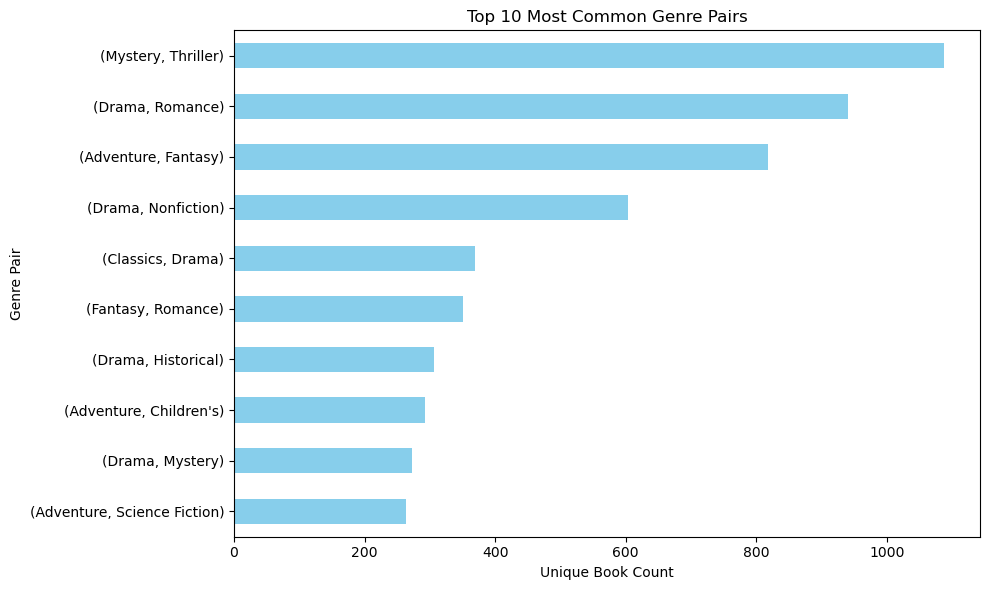

In [65]:
import matplotlib.pyplot as plt

genre_pair_counts.head(10).plot(kind='barh', figsize=(10,6), color='skyblue')
plt.xlabel("Unique Book Count")
plt.ylabel("Genre Pair")
plt.title("Top 10 Most Common Genre Pairs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Hierarchy data - Genre

/tmp/ipykernel_1930894/21152464.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


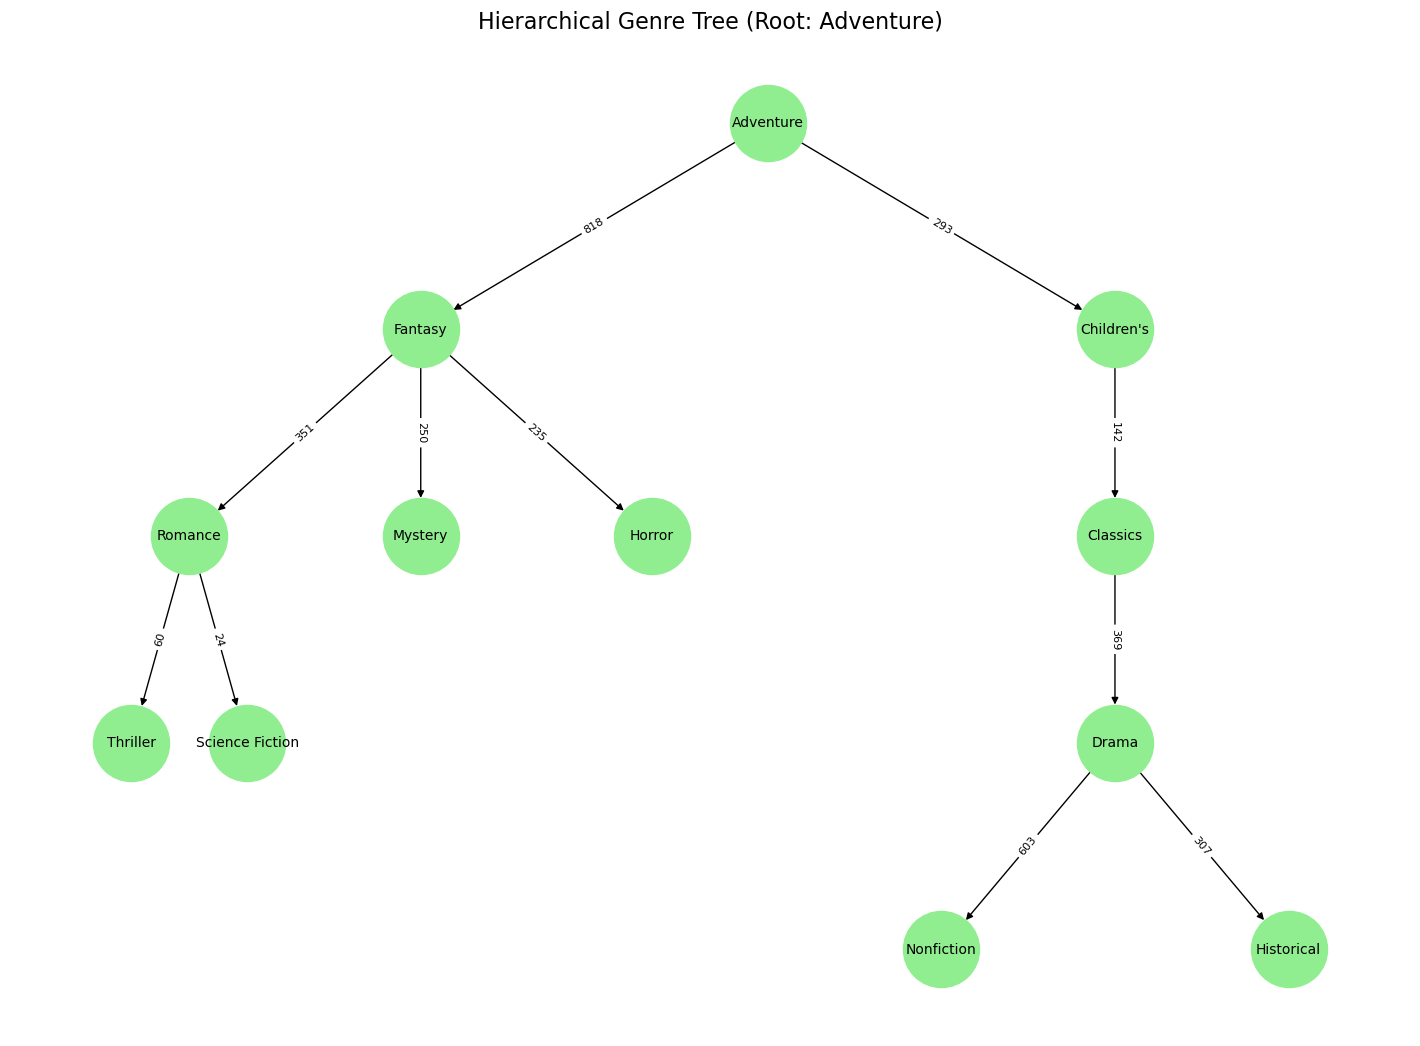

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# Your genre pairs with number of shared books
genre_pairs = {
    ('Adult', 'Classics'): 5, ('Adult', 'Drama'): 144, ('Adult', 'Fantasy'): 2, ('Adult', 'Historical'): 5,
    ('Adult', 'Mystery'): 8, ('Adult', 'Nonfiction'): 24, ('Adult', 'Romance'): 139, ('Adult', 'Thriller'): 4,
    ('Adventure', "Children's"): 293, ('Adventure', 'Classics'): 63, ('Adventure', 'Drama'): 51,
    ('Adventure', 'Fantasy'): 818, ('Adventure', 'Historical'): 48, ('Adventure', 'Horror'): 7,
    ('Adventure', 'Mystery'): 72, ('Adventure', 'Nonfiction'): 76, ('Adventure', 'Romance'): 19,
    ('Adventure', 'Science Fiction'): 264, ('Adventure', 'Thriller'): 78,
    ("Children's", 'Classics'): 142, ("Children's", 'Drama'): 94, ("Children's", 'Fantasy'): 165,
    ("Children's", 'Historical'): 39, ("Children's", 'Horror'): 12, ("Children's", 'Mystery'): 67,
    ("Children's", 'Nonfiction'): 17, ("Children's", 'Romance'): 22, ("Children's", 'Science Fiction'): 12,
    ('Classics', 'Drama'): 369, ('Classics', 'Fantasy'): 25, ('Classics', 'Historical'): 24, 
    ('Classics', 'Horror'): 21, ('Classics', 'Mystery'): 60, ('Classics', 'Nonfiction'): 113,
    ('Classics', 'Romance'): 44, ('Classics', 'Science Fiction'): 35,
    ('Drama', 'Fantasy'): 99, ('Drama', 'Historical'): 307, ('Drama', 'Horror'): 33, ('Drama', 'Mystery'): 272,
    ('Drama', 'Nonfiction'): 603, ('Drama', 'Romance'): 941, ('Drama', 'Science Fiction'): 65,
    ('Drama', 'Thriller'): 28,
    ('Fantasy', 'Historical'): 39, ('Fantasy', 'Horror'): 235, ('Fantasy', 'Mystery'): 250,
    ('Fantasy', 'Nonfiction'): 23, ('Fantasy', 'Romance'): 351, ('Fantasy', 'Science Fiction'): 41,
    ('Fantasy', 'Thriller'): 40,
    ('Historical', 'Horror'): 1, ('Historical', 'Mystery'): 105, ('Historical', 'Nonfiction'): 79,
    ('Historical', 'Romance'): 189, ('Historical', 'Science Fiction'): 8, ('Historical', 'Thriller'): 13,
    ('Horror', 'Mystery'): 232, ('Horror', 'Nonfiction'): 4, ('Horror', 'Romance'): 55,
    ('Horror', 'Science Fiction'): 46, ('Horror', 'Thriller'): 123,
    ('Mystery', 'Nonfiction'): 22, ('Mystery', 'Romance'): 257, ('Mystery', 'Science Fiction'): 130,
    ('Mystery', 'Thriller'): 1088,
    ('Nonfiction', 'Romance'): 30, ('Nonfiction', 'Science Fiction'): 69, ('Nonfiction', 'Thriller'): 11,
    ('Romance', 'Science Fiction'): 24, ('Romance', 'Thriller'): 60,
    ('Science Fiction', 'Thriller'): 161
}

# Step 1: Build the directed graph from pairs
G = nx.DiGraph()
for (g1, g2), weight in genre_pairs.items():
    G.add_edge(g1, g2, weight=weight)

# Step 2: Find the dominant root node (highest outgoing - incoming edge weights)
dominance = {
    node: sum(d['weight'] for _, _, d in G.out_edges(node, data=True)) -
          sum(d['weight'] for _, _, d in G.in_edges(node, data=True))
    for node in G.nodes
}
root_genre = max(dominance, key=dominance.get)

# Step 3: Create a hierarchical tree using DFS from root
def build_tree_from_dag(G, root):
    tree = nx.DiGraph()
    visited = set()

    def dfs(node):
        visited.add(node)
        # sort by weight, get top 3 connections
        children = sorted(G.successors(node), key=lambda x: -G[node][x]['weight'])[:3]
        for child in children:
            if child not in visited:
                tree.add_edge(node, child, weight=G[node][child]['weight'])
                dfs(child)

    dfs(root)
    return tree

tree = build_tree_from_dag(G, root_genre)

# Step 4: Create a hierarchy layout
def hierarchy_pos(G, root=None, width=1.0, vert_gap=0.3, vert_loc=0, xcenter=0.5,
                  pos=None, parent=None):
    if pos is None:
        pos = {root: (xcenter, vert_loc)}
    else:
        pos[root] = (xcenter, vert_loc)
    children = list(G.successors(root))
    if len(children) != 0:
        dx = width / len(children)
        nextx = xcenter - width / 2 - dx / 2
        for child in children:
            nextx += dx
            pos = hierarchy_pos(G, root=child, width=dx, vert_gap=vert_gap,
                                vert_loc=vert_loc - vert_gap, xcenter=nextx, pos=pos, parent=root)
    return pos

# Step 5: Visualize the tree
pos = hierarchy_pos(tree, root=root_genre)
plt.figure(figsize=(14, 10))
nx.draw(tree, pos, with_labels=True, node_size=3000, node_color='lightgreen', font_size=10, arrows=True)
edge_labels = {(u, v): d['weight'] for u, v, d in tree.edges(data=True)}
nx.draw_networkx_edge_labels(tree, pos, edge_labels=edge_labels, font_size=8)
plt.title(f"Hierarchical Genre Tree (Root: {root_genre})", fontsize=16)
plt.tight_layout()
plt.show()


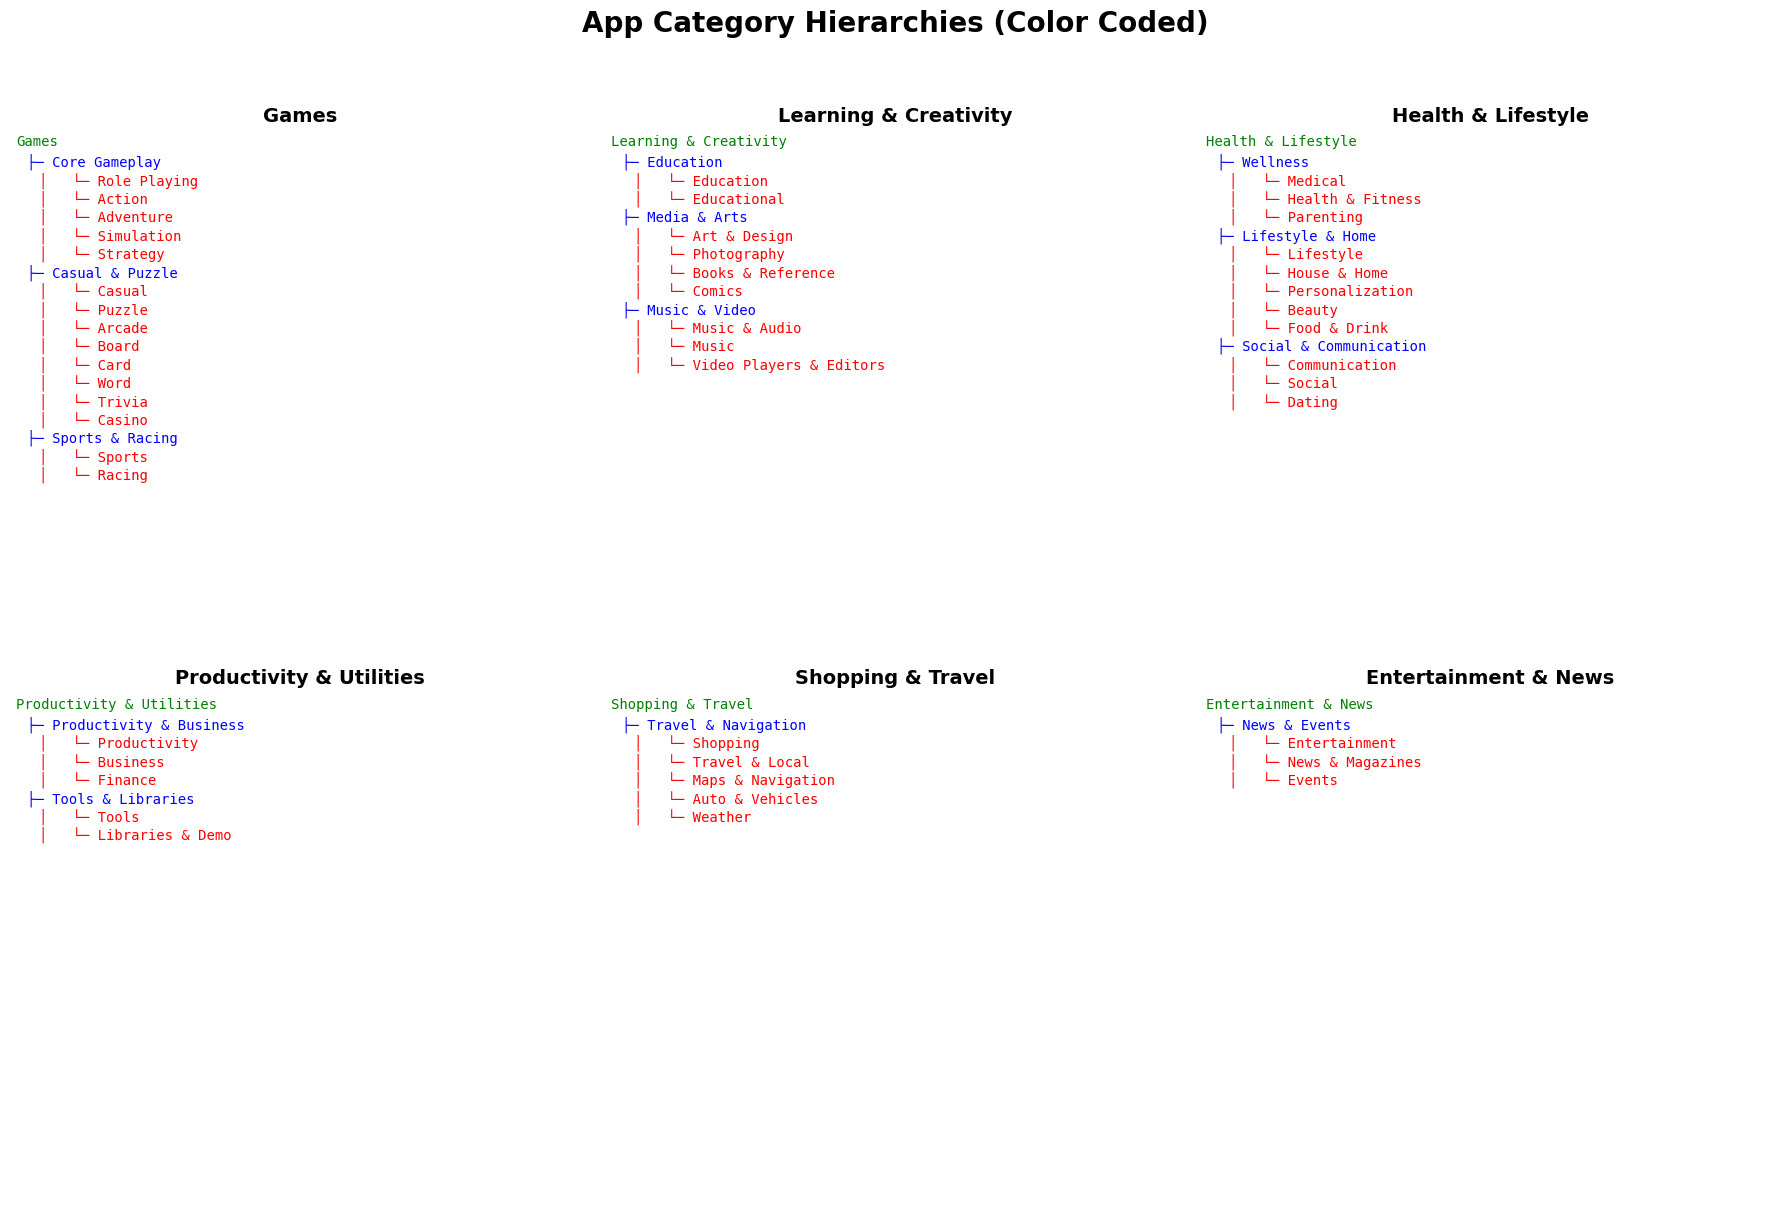

In [ ]:
import matplotlib.pyplot as plt

# Hierarchy data as a dictionary
hierarchy = {
    "Games": {
        "Core Gameplay": [
            "Role Playing", "Action", "Adventure", "Simulation", "Strategy"
        ],
        "Casual & Puzzle": [
            "Casual", "Puzzle", "Arcade", "Board", "Card", "Word", "Trivia", "Casino"
        ],
        "Sports & Racing": [
            "Sports", "Racing"
        ]
    },
    "Learning & Creativity": {
        "Education": [
            "Education", "Educational"
        ],
        "Media & Arts": [
            "Art & Design", "Photography", "Books & Reference", "Comics"
        ],
        "Music & Video": [
            "Music & Audio", "Music", "Video Players & Editors"
        ]
    },
    "Health & Lifestyle": {
        "Wellness": [
            "Medical", "Health & Fitness", "Parenting"
        ],
        "Lifestyle & Home": [
            "Lifestyle", "House & Home", "Personalization", "Beauty", "Food & Drink"
        ],
        "Social & Communication": [
            "Communication", "Social", "Dating"
        ]
    },
    "Productivity & Utilities": {
        "Productivity & Business": [
            "Productivity", "Business", "Finance"
        ],
        "Tools & Libraries": [
            "Tools", "Libraries & Demo"
        ]
    },
    "Shopping & Travel": {
        "Travel & Navigation": [
            "Shopping" , "Travel & Local", "Maps & Navigation", "Auto & Vehicles", "Weather"
        ]
    },
    "Entertainment & News": {
        "News & Events": [
            "Entertainment", "News & Magazines", "Events"
        ]
    }
}

# Determine layout: 3 rows x 3 cols (to fit 6-7 trees neatly)
n = len(hierarchy)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 6))

# Flatten axes for easy iteration, pad with None if fewer subplots than grid
axes = axes.flatten()
for ax in axes[n:]:
    ax.axis('off')  # Hide any unused subplots

# Render each main category tree
for i, (main_category, sub_tree) in enumerate(hierarchy.items()):
    ax = axes[i]
    
    y = 0.99  # Start from top of the axes
    line_height = 0.035  # Vertical spacing between lines
    
    # Root: green
    ax.text(0.01, y, main_category, va='top', ha='left', family='monospace', fontsize=10, color='green')
    y -= line_height
    
    for sub, leaves in sub_tree.items():
        # First-level children: blue
        ax.text(0.03, y, f"├─ {sub}", va='top', ha='left', family='monospace', fontsize=10, color='blue')
        y -= line_height
        
        for leaf in leaves:
            # Second-level children: red
            ax.text(0.05, y, f"│   └─ {leaf}", va='top', ha='left', family='monospace', fontsize=10, color='red')
            y -= line_height
    
    ax.axis('off')
    ax.set_title(f"{main_category}", fontsize=14, weight='bold')

plt.tight_layout()
plt.suptitle("App Category Hierarchies (Color Coded)", fontsize=20, weight='bold', y=1.02)
plt.subplots_adjust(top=0.92)
plt.show()


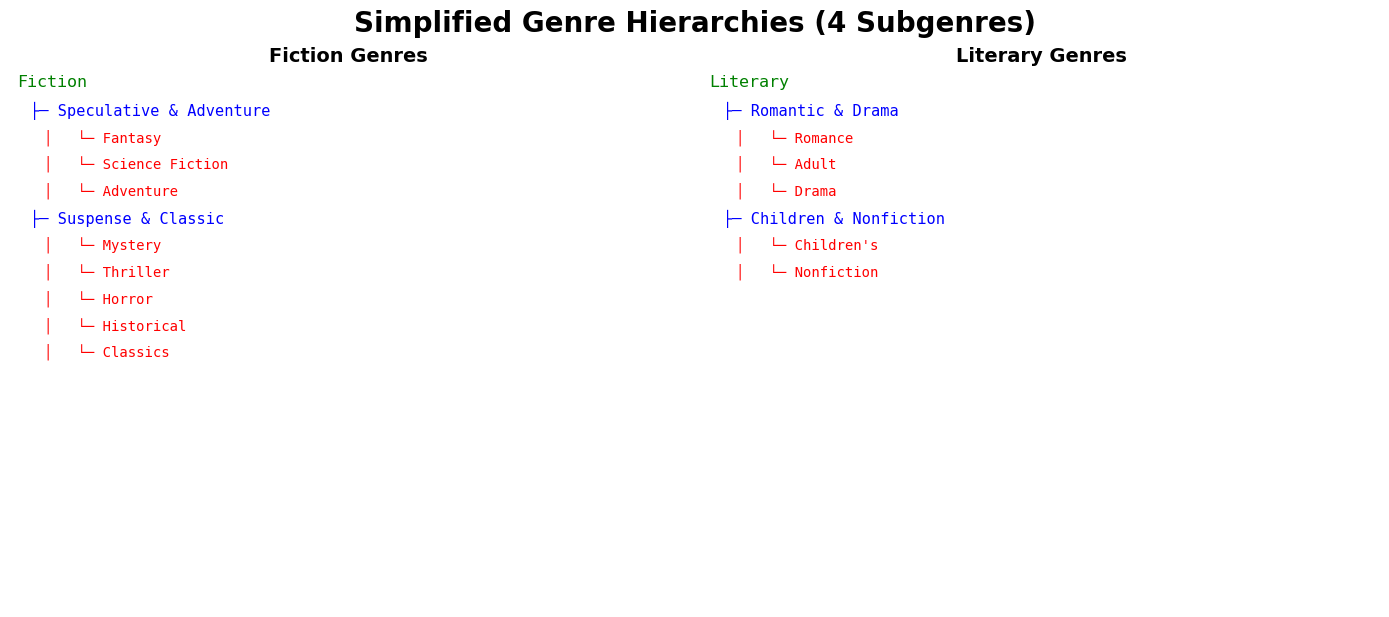

In [ ]:
import matplotlib.pyplot as plt

# Simplified hierarchy
genre_hierarchy = {
    "Fiction": {
        "Speculative & Adventure": ["Fantasy", "Science Fiction", "Adventure"],
        "Suspense & Classic": ["Mystery", "Thriller", "Horror", "Historical", "Classics"]
    },
    "Literary": {
        "Romantic & Drama": ["Romance", "Adult", "Drama"],
        "Children & Nonfiction": ["Children's", "Nonfiction"]
    }
}

# Determine layout: one row per main category
n = len(genre_hierarchy)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 6))
axes = axes.flatten()
for ax in axes[n:]:
    ax.axis('off')  # Hide unused subplots

# Render each main genre tree
for i, (main_category, sub_tree) in enumerate(genre_hierarchy.items()):
    ax = axes[i]
    
    y = 0.99
    line_height = 0.05
    
    # Root: green
    ax.text(0.01, y, main_category, va='top', ha='left', family='monospace', fontsize=12, color='green')
    y -= line_height
    
    for sub, leaves in sub_tree.items():
        # Subcategories: blue
        ax.text(0.03, y, f"├─ {sub}", va='top', ha='left', family='monospace', fontsize=11, color='blue')
        y -= line_height
        
        for leaf in leaves:
            # Leaves: red
            ax.text(0.05, y, f"│   └─ {leaf}", va='top', ha='left', family='monospace', fontsize=10, color='red')
            y -= line_height
    
    ax.axis('off')
    ax.set_title(f"{main_category} Genres", fontsize=14, weight='bold')

plt.tight_layout()
plt.suptitle("Simplified Genre Hierarchies (4 Subgenres)", fontsize=20, weight='bold', y=1.02)
plt.subplots_adjust(top=0.92)
plt.show()


### working with OPenAI API